## Downloading data

We will use [New York City yellow taxi trips](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) from 2024. This is a typical raw input to ML pipelines, with individual events as rows. We will download full 2024 data. Due to its size, it's already distributed as Parquet files. Feature descriptions are available [as a data dictionary document](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf).

In [1]:
import os
import subprocess

DATA_DIR = "data"
if not os.path.exists(DATA_DIR):
    os.mkdir(DATA_DIR)


for month in range(1, 13):
    if not os.path.exists(f"{DATA_DIR}/{month}.parquet"):
        subprocess.run(
            [
                "wget",
                f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-{month:02}.parquet",
                "-O",
                f"{DATA_DIR}/{month}.parquet",
            ]
        )


total_size = sum(
    os.path.getsize(f"{DATA_DIR}/{month}.parquet") for month in range(1, 13)
)
sum(os.path.getsize(f"{DATA_DIR}/{month}.parquet") for month in range(1, 13))

693001713

For later queries, we will also download mapping for location IDs.

In [2]:
if not os.path.exists(f"{DATA_DIR}/taxi_zone_lookup.csv"):
    subprocess.run(
        [
            "wget",
            "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv",
            "-O",
            f"{DATA_DIR}/taxi_zone_lookup.csv",
        ]
    )

In [4]:
import polars as pl

df_taxi_zones = pl.read_csv("data/taxi_zone_lookup.csv")

## include only rides starting in 2024 and ending at most at 01.01.2025

In [5]:
dfs = []
DATA_DIR = "data"

for month in range(1, 13):
    df = pl.scan_parquet(f"{DATA_DIR}/{month}.parquet")
    df = df.with_columns(
        pl.col("tpep_pickup_datetime").dt.cast_time_unit("ms"),
        pl.col("tpep_dropoff_datetime").dt.cast_time_unit("ms"),
    )
    dfs.append(df)

df = pl.concat(dfs)
df = df.filter(
    (pl.col("tpep_pickup_datetime").dt.year() >= 2024)
    & (pl.col("tpep_pickup_datetime").dt.year() < 2025)
)

base_df = df

## optimize data types, particularly for integers and categorical strings


In [6]:
df = df.with_columns(
    pl.col("passenger_count").cast(pl.UInt8),
    pl.col("payment_type").cast(pl.UInt8),
    pl.col("RatecodeID").cast(pl.Int16),
    pl.col("PULocationID").cast(pl.Int16),
    pl.col("store_and_fwd_flag").replace_strict({"Y": 1, "N": 0}).cast(pl.Boolean),
    pl.col(pl.Float64).cast(pl.Float32),
)

In [7]:
df.columns

/tmp/ipykernel_5760/2420516957.py:1: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  df.columns


['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee']

In [8]:
df.collect().head(5)

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
i32,datetime[ms],datetime[ms],u8,f32,i16,bool,i16,i32,u8,f32,f32,f32,f32,f32,f32,f32,f32,f32
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,false,186,79,2,17.700001,1.0,0.5,0.0,0.0,1.0,22.700001,2.5,0.0
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,false,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,false,236,79,1,23.299999,3.5,0.5,3.0,0.0,1.0,31.299999,2.5,0.0
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,false,79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,false,211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0


## 2. Data cleaning and filtering


In [9]:
money_columns = [
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "congestion_surcharge",
    "Airport_fee",
]

vendor_value = {1, 2, 6, 7}
ratecode_value = {1, 2, 3, 4, 5, 6, 99}

In [10]:
type(df)

polars.lazyframe.frame.LazyFrame

In [11]:
df = (
    df.with_columns(pl.col("passenger_count").fill_null(1))
    .filter(pl.col("passenger_count") > 0)
    .with_columns(pl.when(pl.col("passenger_count") > 6).then(pl.lit(6)))
    .with_columns(
        (pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime"))
        .dt.total_minutes()
        .alias("trip_time")
    )
    .filter(pl.col("trip_time") <= 120)
    .with_columns(pl.col(money_columns).abs())
    .filter(all(money_columns) < 1000)
    .filter(
        (pl.col("VendorID").is_in(vendor_value))
        & (pl.col("RatecodeID").is_in(ratecode_value))
    )
)

## 3. Data transformation

In [12]:
other_payment_type = {0, 3, 4, 5, 6}

In [13]:
lookup_df_taxi_zone = df_taxi_zones.select(["LocationID", "Borough"]).lazy()

In [14]:
pickup_time = pl.col("tpep_pickup_datetime").dt.time()

rush_morning = (pickup_time >= pl.time(6, 30)) & (pickup_time < pl.time(9, 30))

rush_evening = (pickup_time >= pl.time(15, 30)) & (pickup_time < pl.time(20, 0))

is_in_time_slot = rush_morning | rush_evening

In [15]:
df_taxi_zones.head(5)

LocationID,Borough,Zone,service_zone
i64,str,str,str
1,"""EWR""","""Newark Airport""","""EWR"""
2,"""Queens""","""Jamaica Bay""","""Boro Zone"""
3,"""Bronx""","""Allerton/Pelham Gardens""","""Boro Zone"""
4,"""Manhattan""","""Alphabet City""","""Yellow Zone"""
5,"""Staten Island""","""Arden Heights""","""Boro Zone"""


In [16]:
df = (
    df.with_columns(
        pl.when(pl.col("payment_type").is_in(other_payment_type)).then(pl.lit(0))
    )
    .join(
        lookup_df_taxi_zone, left_on="PULocationID", right_on="LocationID", how="left"
    )
    .rename({"Borough": "Pickup_Borough"})
    .join(
        lookup_df_taxi_zone, left_on="DOLocationID", right_on="LocationID", how="left"
    )
    .rename({"Borough": "Dropoff_Borough"})
    .with_columns((pl.col("Airport_fee") > 0).alias("is_airport_ride"))
    .with_columns(
        ((pl.col("tpep_dropoff_datetime").dt.weekday() > 5) & is_in_time_slot).alias(
            "is_rush_hour"
        )
    )
)

In [17]:
df = df.collect()

In [18]:
df.head(5)

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,literal,trip_time,Pickup_Borough,Dropoff_Borough,is_airport_ride,is_rush_hour
i32,datetime[ms],datetime[ms],u8,f32,i16,bool,i16,i32,u8,f32,f32,f32,f32,f32,f32,f32,f32,f32,i32,i64,str,str,bool,bool
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,false,186,79,2,17.700001,1.0,0.5,0.0,0.0,1.0,22.700001,2.5,0.0,null,19,"""Manhattan""","""Manhattan""",false,false
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,false,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0,null,6,"""Manhattan""","""Manhattan""",false,false
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,false,236,79,1,23.299999,3.5,0.5,3.0,0.0,1.0,31.299999,2.5,0.0,null,17,"""Manhattan""","""Manhattan""",false,false
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,false,79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0,null,8,"""Manhattan""","""Manhattan""",false,false
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,false,211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0,null,6,"""Manhattan""","""Manhattan""",false,false


## 4. Feature extraction

In [19]:
categorical_cols_to_dummy = ["payment_type", "Pickup_Borough", "Dropoff_Borough"]

df = df.to_dummies(categorical_cols_to_dummy)

In [20]:
time_features = df.lazy().with_columns(
    [
        pl.col("tpep_pickup_datetime").dt.ordinal_day().alias("day_of_year"),
        pl.col("tpep_pickup_datetime").dt.quarter().alias("quarter"),
        pl.col("tpep_pickup_datetime").dt.month().alias("month"),
        pl.col("tpep_pickup_datetime").dt.day().alias("day_of_month"),
        pl.col("tpep_pickup_datetime").dt.weekday().alias("day_of_week"),
        (pl.col("tpep_pickup_datetime").dt.weekday() > 5).alias("is_weekend"),
        pl.col("tpep_pickup_datetime").dt.date().alias("date"),
    ]
)

In [21]:
time_features = df.lazy().with_columns(
    [
        pl.col("tpep_pickup_datetime").dt.ordinal_day().alias("day_of_year"),
        pl.col("tpep_pickup_datetime").dt.quarter().alias("quarter"),
        pl.col("tpep_pickup_datetime").dt.month().alias("month"),
        pl.col("tpep_pickup_datetime").dt.day().alias("day_of_month"),
        pl.col("tpep_pickup_datetime").dt.weekday().alias("day_of_week"),
        (pl.col("tpep_pickup_datetime").dt.weekday() > 5).alias("is_weekend"),
        pl.col("tpep_pickup_datetime").dt.date().alias("date"),
    ]
)


aggregated_df = (
    time_features.group_by(
        [
            "date",
            "day_of_year",
            "quarter",
            "month",
            "day_of_month",
            "day_of_week",
            "is_weekend",
        ]
    )
    .agg(
        [
            pl.count("VendorID").alias("number_of_rides"),
            pl.col("VendorID")
            .filter("is_airport_ride")
            .len()
            .alias("number_of_airport_rides"),
            pl.col("VendorID")
            .filter("is_rush_hour")
            .len()
            .alias("number_of_rush_hour_rides"),
            pl.mean("fare_amount").alias("avg_fare_amount"),
            pl.median("trip_distance").alias("median_trip_dist"),
            pl.sum("total_amount").alias("sum_total_amount"),
            pl.sum("congestion_surcharge").alias("tot_congestion_surcharge"),
            pl.sum("passenger_count").alias("tot_num_of_passengers"),
            pl.col("payment_type_1").sum().alias("tot_amount_card"),
            pl.col("payment_type_2").sum().alias("tot_amount_cash"),
            pl.col("payment_type_3").sum().alias("tot_amount_other"),
        ]
    )
    .sort("date")
    .collect()
)

In [22]:
aggregated_df.head(5)

date,day_of_year,quarter,month,day_of_month,day_of_week,is_weekend,number_of_rides,number_of_airport_rides,number_of_rush_hour_rides,avg_fare_amount,median_trip_dist,sum_total_amount,tot_congestion_surcharge,tot_num_of_passengers,tot_amount_card,tot_amount_cash,tot_amount_other
date,i16,i8,i8,i8,i8,bool,u32,u32,u32,f32,f32,f32,f32,i64,i64,i64,i64
2024-01-01,1,1,1,1,1,false,69665,8352,0,22.217703,2.09,2.185003e6,156123.25,109145,52970,14491,565
2024-01-02,2,1,1,2,2,false,72585,9828,0,21.506176,1.82,2.250542e6,160617.5,104079,55175,15388,643
2024-01-03,3,1,1,3,3,false,79566,9140,0,20.170843,1.75,2.332076e6,177985.0,110976,61343,16202,592
2024-01-04,4,1,1,4,4,false,99077,8270,0,18.866079,1.75,2.7605e6,226627.5,135817,78738,17994,647
2024-01-05,5,1,1,5,5,false,98860,7460,0,18.246851,1.7,2.6768e6,227542.5,137168,78701,17699,717


In [27]:
aggregated_df.write_parquet("data/dataset.parquet")

## 5. Data analysis

In [23]:
aggregated_df.shape

(366, 18)

In [24]:
aggregated_df.head()

date,day_of_year,quarter,month,day_of_month,day_of_week,is_weekend,number_of_rides,number_of_airport_rides,number_of_rush_hour_rides,avg_fare_amount,median_trip_dist,sum_total_amount,tot_congestion_surcharge,tot_num_of_passengers,tot_amount_card,tot_amount_cash,tot_amount_other
date,i16,i8,i8,i8,i8,bool,u32,u32,u32,f32,f32,f32,f32,i64,i64,i64,i64
2024-01-01,1,1,1,1,1,false,69665,8352,0,22.217703,2.09,2.185003e6,156123.25,109145,52970,14491,565
2024-01-02,2,1,1,2,2,false,72585,9828,0,21.506176,1.82,2.250542e6,160617.5,104079,55175,15388,643
2024-01-03,3,1,1,3,3,false,79566,9140,0,20.170843,1.75,2.332076e6,177985.0,110976,61343,16202,592
2024-01-04,4,1,1,4,4,false,99077,8270,0,18.866079,1.75,2.7605e6,226627.5,135817,78738,17994,647
2024-01-05,5,1,1,5,5,false,98860,7460,0,18.246851,1.7,2.6768e6,227542.5,137168,78701,17699,717


In [25]:
aggregated_df.describe()

statistic,date,day_of_year,quarter,month,day_of_month,day_of_week,is_weekend,number_of_rides,number_of_airport_rides,number_of_rush_hour_rides,avg_fare_amount,median_trip_dist,sum_total_amount,tot_congestion_surcharge,tot_num_of_passengers,tot_amount_card,tot_amount_cash,tot_amount_other
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""366""",366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""","""2024-07-01 12:00:00""",183.5,2.505464,6.513661,15.756831,3.986339,0.284153,100100.076503,8979.103825,9088.18306,19.972021,1.718675,2.913422e6,230208.484375,134966.442623,82243.833333,14924.098361,769.663934
"""std""",null,105.799338,1.119551,3.455958,8.823592,2.006108,null,15371.439577,1715.76066,14678.427338,1.234882,0.100871,463238.84375,37862.421875,18723.865307,14160.570966,1357.346669,114.88853
"""min""","""2024-01-01""",1.0,1.0,1.0,1.0,1.0,0.0,47391.0,3355.0,0.0,16.676249,1.5,1.3260e6,107825.0,74199.0,34052.0,10244.0,440.0
"""25%""","""2024-04-01""",92.0,2.0,4.0,8.0,2.0,null,89573.0,7869.0,0.0,19.125853,1.66,2581948.5,203501.0,122222.0,72543.0,14109.0,695.0
"""50%""","""2024-07-02""",184.0,3.0,7.0,16.0,4.0,null,100782.0,9020.0,0.0,19.96929,1.7,2.9213e6,232825.0,134084.0,83419.0,14966.0,771.0
"""75%""","""2024-10-01""",275.0,4.0,10.0,23.0,6.0,null,110805.0,10144.0,26219.0,20.758921,1.77,3.2294e6,256942.0,147192.0,91739.0,15836.0,844.0
"""max""","""2024-12-31""",366.0,4.0,12.0,31.0,7.0,1.0,141702.0,14904.0,46124.0,24.85223,2.2,4.464577e6,330475.0,199445.0,120997.0,17994.0,1087.0


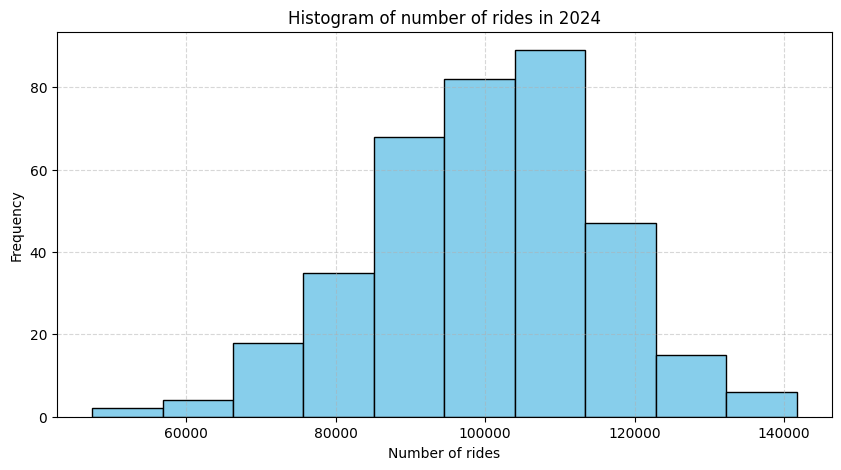

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(aggregated_df["number_of_rides"], bins=10, color="skyblue", edgecolor="black")
plt.title("Histogram of number of rides in 2024")
plt.xlabel("Number of rides")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

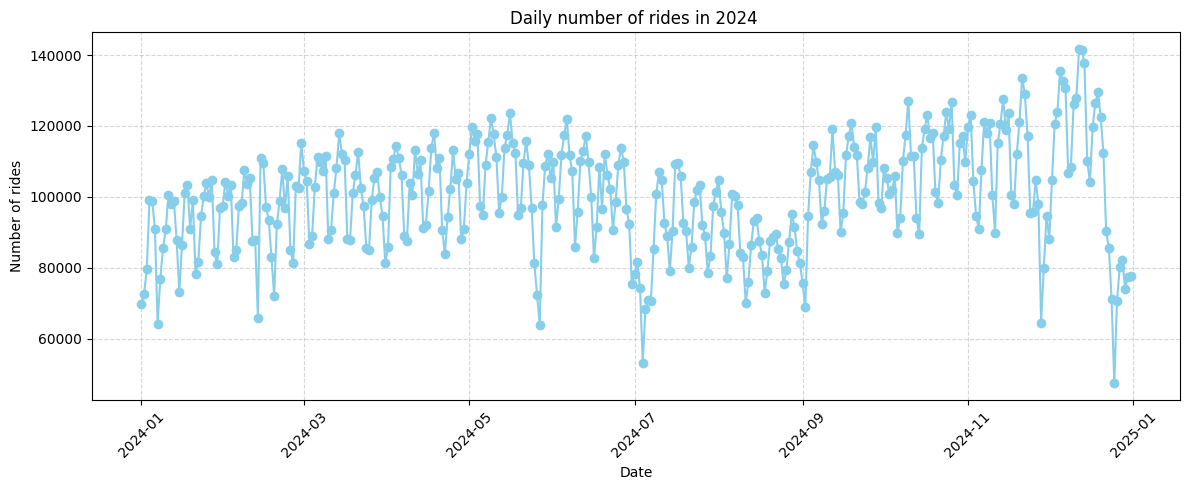

In [48]:
plt.figure(figsize=(12, 5))
plt.plot(
    aggregated_df["date"],
    aggregated_df["number_of_rides"],
    marker="o",
    linestyle="-",
    color="skyblue",
)
plt.title("Daily number of rides in 2024 ")
plt.xlabel("Date")
plt.ylabel("Number of rides")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()